In [1]:
!git clone https://github.com/Tahoni01/Continual-hate-speech-detection.git
%cd Continual-hate-speech-detection
!ls

Cloning into 'Continual-hate-speech-detection'...
remote: Enumerating objects: 150, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 150 (delta 55), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (150/150), 203.67 KiB | 2.71 MiB/s, done.
Resolving deltas: 100% (55/55), done.
/content/Continual-hate-speech-detection
dataset     models	    README.md	      src	utils
Main.ipynb  old_main.ipynb  requirements.txt  strategy


In [2]:
import torch
from dataset.df_loader import (getdf_davidson, getdf_hatexplain)
from dataset.stream_generator import (create_continual_stream, online_stream)
from transformers import (AutoTokenizer, AutoConfig)
from models.model_builder import CustomClassifier
from models.trainer import ContinualTrainer

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", device)

DEVICE: cuda


In [4]:
print("Loading datasets...")

df_dv = getdf_davidson()
df_hx = getdf_hatexplain()

print("Davidson:", df_dv.shape)
print("HateXplain:", df_hx.shape)

Loading datasets...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.63M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24783 [00:00<?, ? examples/s]

                                                text      label    source
0  rt as a woman you shouldnt complain about clea...     normal  davidson
1  rt boy dats coldtyga dwn bad for cuffin dat ho...  offensive  davidson
2  rt dawg rt you ever fuck a bitch and she start...  offensive  davidson
3                          rt she look like a tranny  offensive  davidson
4  rt the shit you hear about me might be true or...  offensive  davidson
                                                text       label      source
0  i dont think im getting my baby them white 9 h...      normal  hatexplain
1  we cannot continue calling ourselves feminists...      normal  hatexplain
2                      nawt yall niggers ignoring me      normal  hatexplain
3  user i am bit confused coz chinese ppl can not...  hatespeech  hatexplain
4  this bitch in whataburger eating a burger with...  hatespeech  hatexplain
Davidson: (24275, 3)
HateXplain: (20144, 3)


In [5]:
full_stream = create_continual_stream(
    df_list=[df_dv, df_hx],
    batch_size=10
)

In [6]:
tokenizer = AutoTokenizer.from_pretrained("distilroberta-base")

model = CustomClassifier(
    model_name="distilroberta-base",
    num_labels=3
)

model.to(device)

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CustomClassifier(
  (backbone): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Lay

In [7]:
batch = next(iter(online_stream(full_stream)))

# tokenizzazione
encodings = tokenizer(
    batch["text"].tolist(),
    padding=True,
    truncation=True,
    return_tensors="pt"
).to(device)

# conversione label
label_map = {"hatespeech": 0, "offensive": 1, "normal": 2}
labels = torch.tensor([label_map[x] for x in batch["label"].tolist()], dtype=torch.long).to(device)

# forward
outputs = model(
    input_ids=encodings["input_ids"],
    attention_mask=encodings["attention_mask"],
    labels=labels
)

print(outputs.loss, outputs.logits.shape)

preds = torch.argmax(outputs.logits, dim=1)
print(preds)

tensor(1.0652, device='cuda:0', grad_fn=<NllLossBackward0>) torch.Size([10, 3])
tensor([1, 1, 1, 1, 1, 1, 1, 0, 1, 0], device='cuda:0')


In [18]:
test_stream = full_stream[:50]  # solo 2 batch per controllare

trainer = ContinualTrainer(model=model, tokenizer=tokenizer, device=device, batch_size=10)

losses, preds, labels = trainer.train_continual(test_stream, log_every=1)

print("Loss per batch:", losses)
for i, (p, l) in enumerate(zip(preds, labels)):
    print(f"Batch {i+1} predizioni:", p.tolist())
    print(f"Batch {i+1} etichette:", l.tolist())

Training:   4%|▍         | 2/50 [00:00<00:03, 12.66it/s]

Batch 1/50 | Avg loss: 0.1773
Batch 2/50 | Avg loss: 0.0276
Batch 3/50 | Avg loss: 0.6837


Training:  12%|█▏        | 6/50 [00:00<00:02, 15.49it/s]

Batch 4/50 | Avg loss: 0.1089
Batch 5/50 | Avg loss: 0.5455
Batch 6/50 | Avg loss: 0.1248
Batch 7/50 | Avg loss: 0.0447


Training:  20%|██        | 10/50 [00:00<00:02, 16.42it/s]

...

Batch 40/50 | Avg loss: 0.3257
Batch 41/50 | Avg loss: 0.2283
Batch 42/50 | Avg loss: 0.2335
Batch 43/50 | Avg loss: 0.1394


Training:  92%|█████████▏| 46/50 [00:02<00:00, 17.03it/s]

Batch 44/50 | Avg loss: 0.3650
Batch 45/50 | Avg loss: 0.0326
Batch 46/50 | Avg loss: 0.2847
Batch 47/50 | Avg loss: 0.5360


Training: 100%|██████████| 50/50 [00:02<00:00, 17.16it/s]

Batch 48/50 | Avg loss: 0.1094
Batch 49/50 | Avg loss: 0.9382
Batch 50/50 | Avg loss: 0.4785
Loss per batch: [0.17731764912605286, 0.02761288359761238, 0.6837149858474731, 0.10888336598873138, 0.5454585552215576, 0.12484502792358398, 0.0447249673306942, 0.2421981394290924, 0.18628664314746857, 0.07300445437431335, 0.4424663186073303, 0.1513395607471466, 0.25831058621406555, 0.1672322303056717, 0.19785428047180176, 0.2078186720609665, 0.4106331765651703, 0.22412338852882385, 0.07486534863710403, 0.3939770758152008, 0.1827489286661148, 0.2408125400543213, 0.5256341695785522, 0.08588387817144394, 0.22092275321483612, 0.054782114923000336, 0.24615511298179626, 0.045267216861248016, 0.059523750096559525, 0.016335394233465195, 0.3710063099861145, 0.11829102039337158, 0.9619129300117493, 0.03545248135924339, 0.30922919511795044, 1.4800273180007935, 0.2872340977191925, 0.5861641764640808, 0.2970368266105652, 0.32567471265792847, 0.22825947403907776, 0.23345699906349182, 0.13944879174232483, 0.

Training:   1%|          | 2/200 [00:00<00:15, 12.52it/s]

Batch 1/200 | Avg loss: 0.8533
Batch 2/200 | Avg loss: 0.8310
Batch 3/200 | Avg loss: 0.6879


Training:   2%|▏         | 4/200 [00:00<00:14, 13.23it/s]

Batch 4/200 | Avg loss: 0.7440
Batch 5/200 | Avg loss: 0.6371


Training:   3%|▎         | 6/200 [00:00<00:19, 10.10it/s]

...

Batch 190/200 | Avg loss: 0.2346
Batch 191/200 | Avg loss: 0.2272
Batch 192/200 | Avg loss: 0.3577
Batch 193/200 | Avg loss: 0.1533


Training:  98%|█████████▊| 197/200 [00:12<00:00, 17.88it/s]

Batch 194/200 | Avg loss: 0.0399
Batch 195/200 | Avg loss: 0.1230
Batch 196/200 | Avg loss: 0.4809
Batch 197/200 | Avg loss: 0.1636


Training: 100%|██████████| 200/200 [00:12<00:00, 15.94it/s]


Batch 198/200 | Avg loss: 0.0539
Batch 199/200 | Avg loss: 0.2996
Batch 200/200 | Avg loss: 0.3039

Accuracy globale: 0.8595, F1 globale: 0.5938

Batch 1 predizioni: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Batch 1 etichette: [1, 1, 1, 1, 0, 2, 1, 2, 1, 1]

Batch 2 predizioni: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Batch 2 etichette: [2, 1, 1, 1, 1, 1, 2, 2, 2, 1]

Batch 3 predizioni: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Batch 3 etichette: [1, 1, 1, 1, 0, 0, 1, 1, 1, 1]

Batch 4 predizioni: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Batch 4 etichette: [1, 1, 2, 1, 1, 1, 1, 0, 2, 1]

Batch 5 predizioni: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Batch 5 etichette: [1, 1, 0, 1, 1, 1, 0, 1, 1, 1]

Batch 6 predizioni: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Batch 6 etichette: [1, 1, 1, 2, 1, 1, 1, 2, 1, 1]

Batch 7 predizioni: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Batch 7 etichette: [2, 1, 2, 1, 1, 1, 1, 1, 2, 2]

Batch 8 predizioni: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Batch 8 etichette: [1, 2, 1, 0, 1, 1, 1, 1, 1, 2]

Batch 9 predizioni: [1, 1, 1, 1, 1, 1,

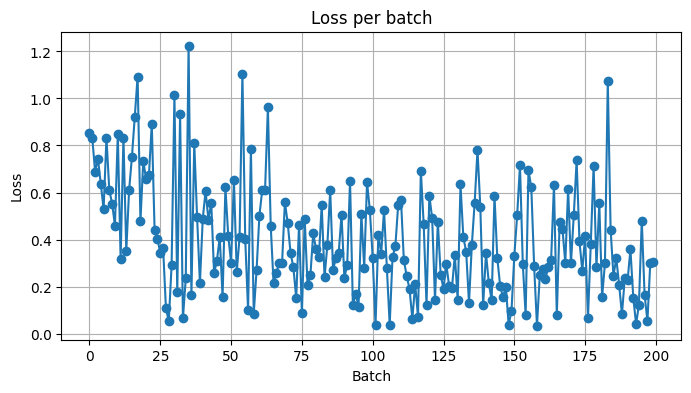

In [10]:
import matplotlib.pyplot as plt
from models.trainer import ContinualTrainer
from strategy.replay import ReplayStrategy
from utils.metrics import compute_accuracy, compute_f1

device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 10

# label map
label_map = {"hatespeech": 0, "offensive": 1, "normal": 2}

# ---------------------------
# Strategy
# ---------------------------
strategy = ReplayStrategy(model=model, buffer_size=50)  # buffer piccolo per test

# ---------------------------
# Trainer
# ---------------------------
trainer = ContinualTrainer(
    model=model,
    tokenizer=tokenizer,
    device=device,
    batch_size=batch_size,
    strategy=strategy  # <-- plug and play
)

# ---------------------------
# Test stream
# ---------------------------
test_stream = full_stream[:200]  # 2 batch da 10 elementi ciascuno, solo per test

# ---------------------------
# Train
# ---------------------------
losses, preds, labels = trainer.train_continual(test_stream, log_every=1)

# ---------------------------
# Metriche globali
# ---------------------------
flat_preds = torch.cat(preds)
flat_labels = torch.cat(labels)

acc = compute_accuracy(flat_preds, flat_labels)
f1 = compute_f1(flat_preds, flat_labels)

print(f"\nAccuracy globale: {acc:.4f}, F1 globale: {f1:.4f}")

# ---------------------------
# Stampa predizioni batch
# ---------------------------
for i, (p, l) in enumerate(zip(preds, labels)):
    print(f"\nBatch {i+1} predizioni:", p.tolist())
    print(f"Batch {i+1} etichette:", l.tolist())

# ---------------------------
# Plot loss
# ---------------------------
plt.figure(figsize=(8,4))
plt.plot(losses, marker='o')
plt.title("Loss per batch")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()